In [1]:
#mounting the google drive to get the access of the dataset.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#accessing the data and assigning it to a variable name.
file_path = '/content/drive/MyDrive/DCS520_Project_Files/coin_Dogecoin.csv'
my_doge_dataset = pd.read_csv(file_path)


def basic_data_viewing(data_frame):
  data_frame.head() #see the first five rows of the data to get familiar with it.
  data_frame.info() #to check the variable types, null values and value count.
  data_frame.describe() #to find the mean, standard deviation
  return data_frame

basic_data_viewing(my_doge_dataset)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2760 entries, 0 to 2759
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SNo        2760 non-null   int64  
 1   Name       2760 non-null   object 
 2   Symbol     2760 non-null   object 
 3   Date       2760 non-null   object 
 4   High       2760 non-null   float64
 5   Low        2760 non-null   float64
 6   Open       2760 non-null   float64
 7   Close      2760 non-null   float64
 8   Volume     2760 non-null   float64
 9   Marketcap  2760 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 215.8+ KB


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Dogecoin,DOGE,2013-12-16 23:59:59,0.000866,0.000150,0.000299,0.000205,0.000000e+00,1.509085e+06
1,2,Dogecoin,DOGE,2013-12-17 23:59:59,0.000289,0.000116,0.000207,0.000269,0.000000e+00,2.169688e+06
2,3,Dogecoin,DOGE,2013-12-18 23:59:59,0.000362,0.000205,0.000267,0.000362,0.000000e+00,3.188943e+06
3,4,Dogecoin,DOGE,2013-12-19 23:59:59,0.001520,0.000328,0.000395,0.001162,0.000000e+00,1.115034e+07
4,5,Dogecoin,DOGE,2013-12-20 23:59:59,0.001143,0.000662,0.001143,0.000704,0.000000e+00,7.284337e+06
...,...,...,...,...,...,...,...,...,...,...
2755,2756,Dogecoin,DOGE,2021-07-02 23:59:59,0.247997,0.238848,0.243982,0.245264,1.321471e+09,3.194925e+10
2756,2757,Dogecoin,DOGE,2021-07-03 23:59:59,0.250214,0.242454,0.245106,0.246411,9.170158e+08,3.210491e+10
2757,2758,Dogecoin,DOGE,2021-07-04 23:59:59,0.252567,0.243425,0.246425,0.246483,9.735115e+08,3.211767e+10
2758,2759,Dogecoin,DOGE,2021-07-05 23:59:59,0.246419,0.227838,0.246419,0.231614,1.267949e+09,3.018344e+10


In [18]:
def clean_data(data):

    # convert Date column to datetime format.
    data['Date'] =pd.to_datetime(data['Date'],errors='coerce')

    # Drop rows with missing dates
    data =data.dropna(subset=['Date'])

    # Remove duplicates
    data = data.drop_duplicates()

    # Fill missing numerical values with forward fill method(or 0 if all NaN)
    data = data.fillna(method='ffill').fillna(0)

    return data

clean_data(my_doge_dataset)

<ipython-input-18-ebe6528e9b92>:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill').fillna(0)


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Dogecoin,DOGE,2013-12-16 23:59:59,0.000866,0.000150,0.000299,0.000205,0.000000e+00,1.509085e+06
1,2,Dogecoin,DOGE,2013-12-17 23:59:59,0.000289,0.000116,0.000207,0.000269,0.000000e+00,2.169688e+06
2,3,Dogecoin,DOGE,2013-12-18 23:59:59,0.000362,0.000205,0.000267,0.000362,0.000000e+00,3.188943e+06
3,4,Dogecoin,DOGE,2013-12-19 23:59:59,0.001520,0.000328,0.000395,0.001162,0.000000e+00,1.115034e+07
4,5,Dogecoin,DOGE,2013-12-20 23:59:59,0.001143,0.000662,0.001143,0.000704,0.000000e+00,7.284337e+06
...,...,...,...,...,...,...,...,...,...,...
2755,2756,Dogecoin,DOGE,2021-07-02 23:59:59,0.247997,0.238848,0.243982,0.245264,1.321471e+09,3.194925e+10
2756,2757,Dogecoin,DOGE,2021-07-03 23:59:59,0.250214,0.242454,0.245106,0.246411,9.170158e+08,3.210491e+10
2757,2758,Dogecoin,DOGE,2021-07-04 23:59:59,0.252567,0.243425,0.246425,0.246483,9.735115e+08,3.211767e+10
2758,2759,Dogecoin,DOGE,2021-07-05 23:59:59,0.246419,0.227838,0.246419,0.231614,1.267949e+09,3.018344e+10


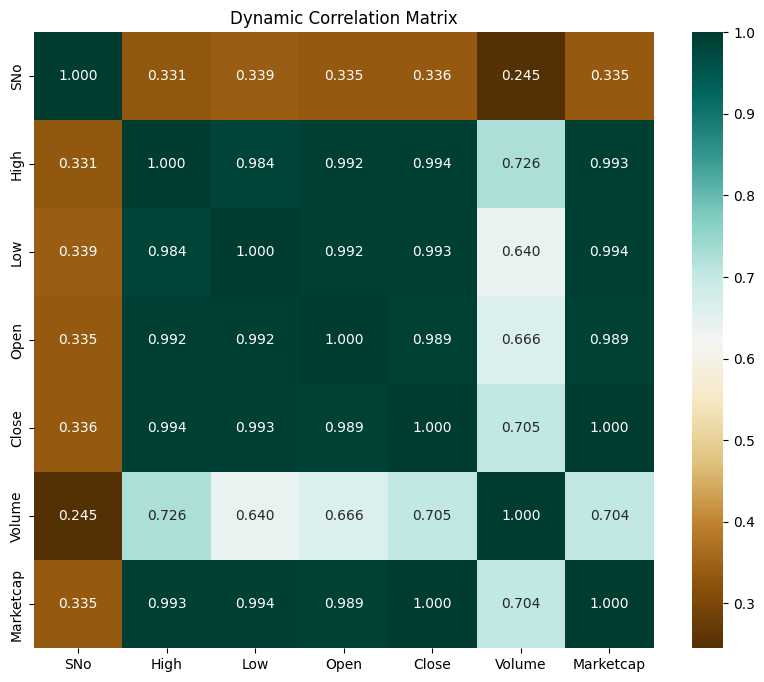

In [8]:
# Creating a function to compute and visualize correlations for numeric variables.

def compute_and_visualize(data, column_to_exclude = None):
    # Exclude the specified column such as serial number or id number etc.
    if column_to_exclude is not None:
        data = data.drop(columns=[column_to_exclude])
    # Compute correlation matrix
    num_data = data.select_dtypes(include= ['float64', 'int64'])
    corr_matrix = num_data.corr()

    #Plotting heatmap
    plt.figure(figsize=(10,8))
    sns.heatmap(corr_matrix, annot=True, cmap='BrBG', fmt='.3f')
    plt.title('Dynamic Correlation Matrix')
    plt.show()

compute_and_visualize(my_doge_dataset, 'Date')

In [ ]:
# Function for statistics tests:

def stats_tests(df):
  #for one sample test
  col_1_sample = input("Enter the first feature for One Sample T-Test: ")
  pop_mean = float(input("Enter the population mean: "))
  t_stat, p_value =stat.ttest_1samp(df[col_1_sample],popmean = pop_mean)
  print(f"One-sample t-test on {col_1_sample}: t-statistic: {t_stat}, p-value: {p_value}\n")

  #for two sample test.
  col_1 =input("Enter the first feature for Two Sample T-Test: ")
  col_2 = input("Enter the second feature for Two Sample T-Test: ")
  t_stat, p_value =stat.ttest_ind(df[col_1], df[col_2])
  print(f"Two sample t-test on {col_1, col_2}: t-statistic: {t_stat}, p-value: {p_value}\n")

  # for paired T test
  col_1 = input("Enter the first feature for Paired T-Test: ")
  col_2 = input("Enter the second feature for Paired T-Test: ")
  t_stat,p_value =stat.ttest_rel( df[col_1], df[col_2])
  print( f"Paired t-test of {col_1, col_2} pair: t-statistic: {t_stat}, p-value: {p_value}\n")

  # to perform ANOVA
  col_1 = input("Enter the first feature for ANOVA: ")
  col_2 = input("Enter the second feature for ANOVA: ")
  col_3 = input("Enter the third feature for ANOVA: ")
  f_stat,p_value = stat.f_oneway (df[col_1], df[col_2], df[col_3])
  print(f"ANOVA between {col_1, col_2, col_3}: f statistic: {f_stat} and p-value: {p_value}\n")

  #to perform linear regression.
  col_1 = input("Enter the feature for Linear Regression: ")

  model = sm.OLS(df['Volume'], sm.add_constant(df[col_1]))
  results = model.fit()
  print(f"\n\nLinear Regression results for {col_1}:\n{results.summary()}")

#calling the function on the dataset.
stats_tests(df)

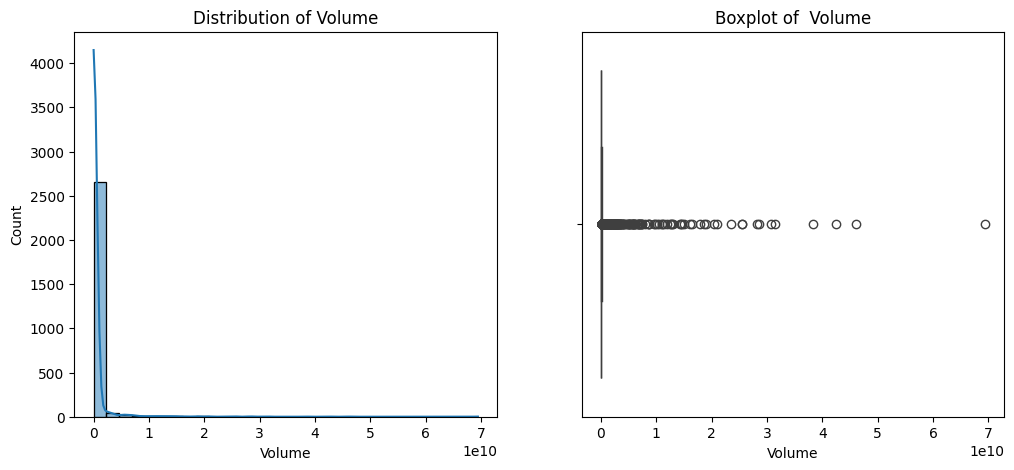

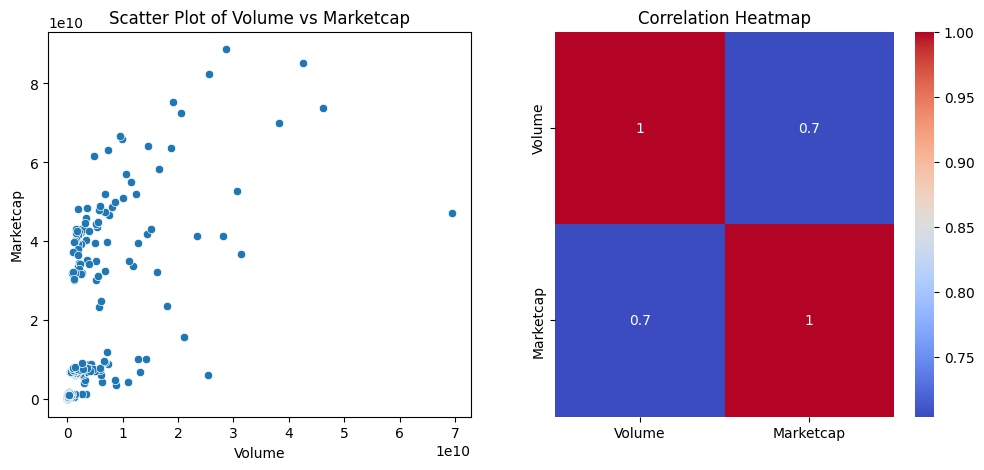

In [14]:
def univariate_analysis(data, column):
    # plot univariate analysis for a feature.
    plt.figure(figsize=(12, 5))

    #plotting a histogram for given column
    plt.subplot(1, 2,1)
    sns.histplot(data [column],bins=30,kde= True)
    plt.title(f'Distribution of {column}')

  #plotting a boxplot for given columns.
    plt.subplot(1,2, 2)
    sns.boxplot(x =data[column])
    plt.title(f'Boxplot of  {column}')
    plt.show()

def bivariate_analysis(data, column1, column2):
  # plot bivariate visualization for two variables.
    plt.figure(figsize=(12,5))

    #creates a scatter plot out of two variables.
    plt.subplot(1, 2,1)
    sns.scatterplot(x=data[column1], y=data[column2])
    plt.title(f'Scatter Plot of {column1} vs {column2}')

    #creates a heatmap to find correlation between two features.
    plt.subplot(1 ,2,2)
    sns.heatmap(data[[column1,column2]].corr(),annot =True,cmap = 'coolwarm')
    plt.title( 'Correlation Heatmap')
    plt.show()


univariate_analysis(my_doge_dataset, 'Volume')
bivariate_analysis(my_doge_dataset, 'Volume', 'Marketcap')